# 使用matplotlib绘制函数图像

学习链接：[Matplotlib 教程](https://www.runoob.com/matplotlib/matplotlib-marker.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_Trajectory(p,det_t):
    for i in range(4):
        theta_i = p[i][1]
        theta_i1 = p[i+1][1]
        theta_i_d = p[i][2]
        theta_i1_d = p[i+1][2]
        a0 = theta_i
        a1 = theta_i_d
        a3 = 3*(theta_i1 - theta_i)/det_t**2 - (theta_i1_d + 2*theta_i_d)/det_t
        a4 = -2*(theta_i1 - theta_i)/det_t**3 + (theta_i1_d + theta_i_d)/det_t**2
        def f(x):
            return a0 + a1*x + a3*x**2 + a4*x**3
        x = np.linspace(0, det_t, 100)
        y = f(x)
        plt.plot(x+i*det_t, y, color=plt.cm.tab10(i))
    plt.title('Trajectory')
    plt.xlabel('时间')
    plt.ylabel('位置')
    plt.legend()
    plt.grid()
    plt.show()
    
p0 = (0,0,0)
p1 = (2,4,7)
p2 = (4,2,0)
p3 = (6,6,7)
p4 = (8,1,0)
p = np.array([p0, p1, p2, p3, p4])    
plot_Trajectory(p,2)

p0 = (0,0,0)
p1 = (2,4,3)
p2 = (4,2,3)
p3 = (6,6,3)
p4 = (8,1,0)
p = np.array([p0, p1, p2, p3, p4])
plot_Trajectory(p,2)

## 一、绘制连续图

## 1. 画单条线
plot([x], y, [fmt], *, data=None, **kwargs)

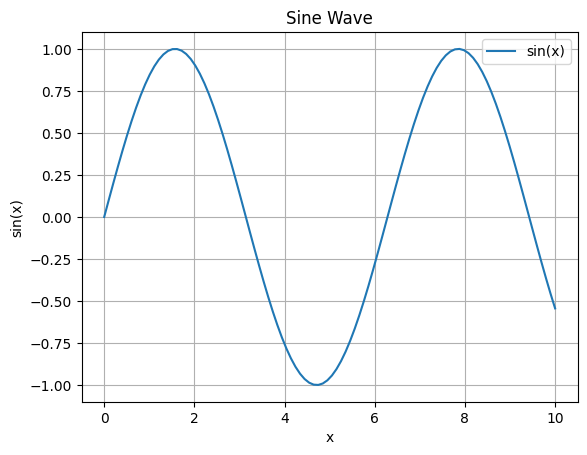

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y, label='sin(x)')

plt.title('Sine Wave')

plt.xlabel('x')
plt.ylabel('sin(x)')

# 显示图例，即图例的标签
# 也可以直接在legend里面添加列表标签，但是如果有多个标签的时候，对应的关系不明显
plt.legend() 

# 添加网格
plt.grid() 

# 保存图像
# plt.savefig('sine_wave.png') 

# 显示图像
plt.show()


## 2. 画多条线（同一图上）
直接多个plot(x, y, fmt)即可


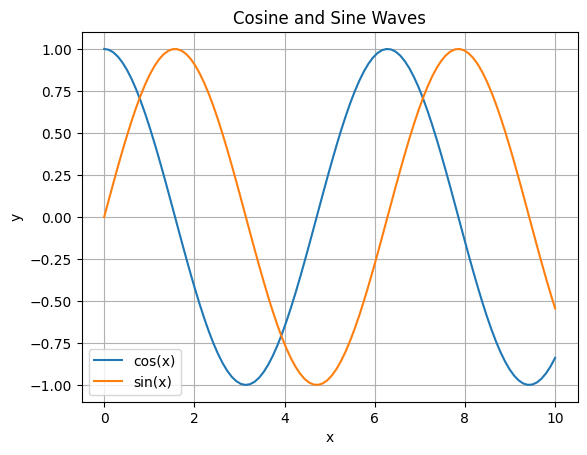

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.cos(x)
y2 = np.sin(x)

## 1. 只使用一个plt.plot()方法，只能在legend中添加标签

# plt.plot(x, y1, x, y2)
# plt.title('Cosine and Sine Waves')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.legend(['cos(x)', 'sin(x)'])  # 添加图例
# plt.grid()
# plt.show()


## 2. 如果想要对应添加标签，只能多次使用plt.plot()

plt.plot(x, y1, label='cos(x)')
plt.plot(x, y2, label='sin(x)')
plt.title('Cosine and Sine Waves')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()  # 显示图例
plt.grid()
plt.show()


## 3. 画多条线（不同图上）
我们可以使用 pyplot 中的 subplot() 和 subplots() 方法来绘制多个子图。

- subplot() 方法在绘图时需要指定位置
- subplots() 方法可以一次生成多个，在调用时只需要调用生成对象的 ax 即可。

---

### subplot()

使用subplot选择对应的绘图格子，然后正常的使用plt.plot()方法即可。

subplot(nrows, ncols, index, **kwargs)

但是需要手动设置各个子图的颜色

---

## subplots()

```python
matplotlib.pyplot.subplots(nrows=1, ncols=1, *, 
    sharex=False, sharey=False, # 是否共享x, y轴的属性
    squeeze=True, 
    subplot_kw=None, gridspec_kw=None, **fig_kw)
```

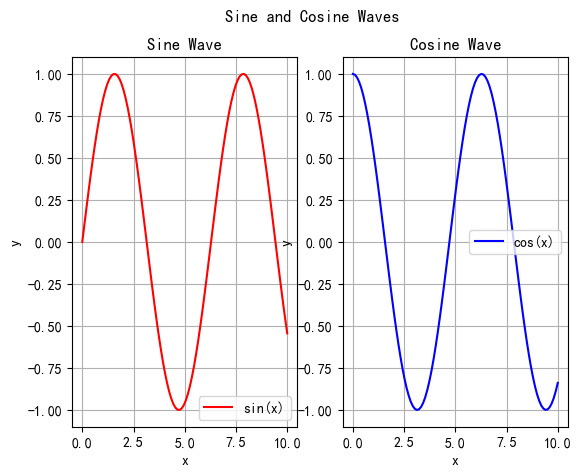

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.subplot(1, 2, 1) # 等价表示subplot(121)，注意索引从1开始
plt.plot(x, y1, label='sin(x)', color='r')  # 绘制第一条线
plt.title('Sine Wave')  # 设置子图标题
plt.xlabel('x')
plt.ylabel('y')
plt.legend()  # 显示图例
plt.grid()

plt.subplot(1, 2,2)
plt.plot(x, y2, label='cos(x)', color='b')  # 绘制第二条线
plt.title('Cosine Wave')  # 设置子图标题
plt.xlabel('x')
plt.ylabel('y')
plt.legend()  # 显示图例
plt.grid()

plt.suptitle('Sine and Cosine Waves')  # 设置总标题

plt.show()

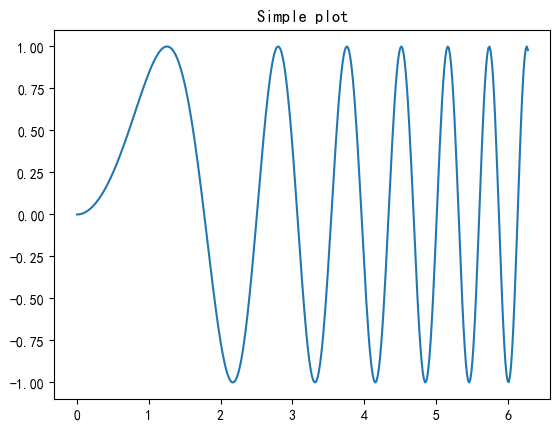

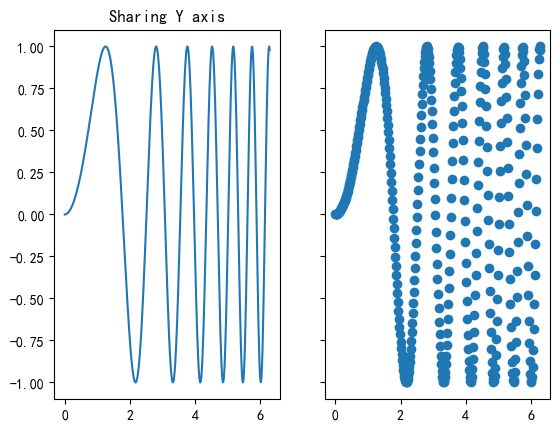

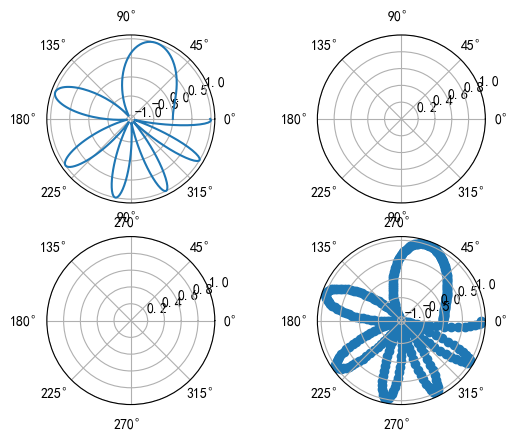

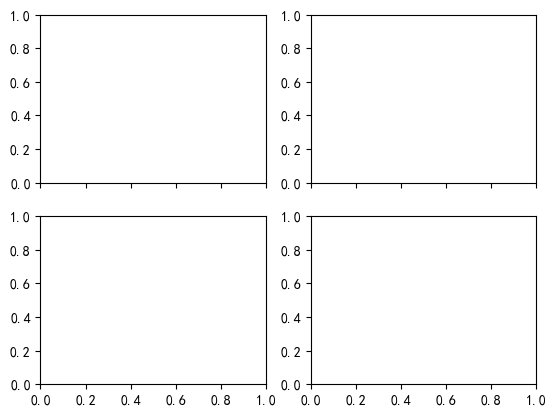

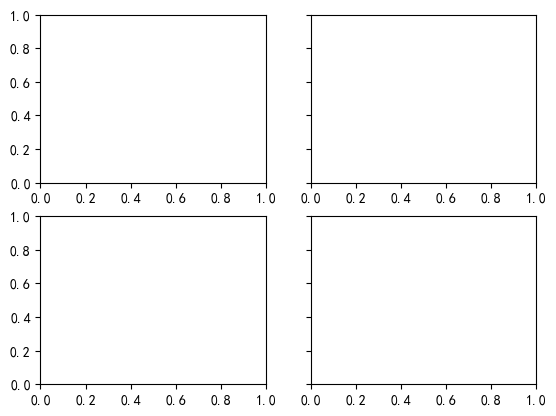

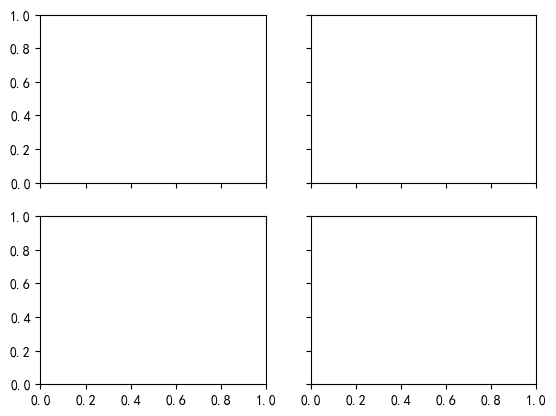

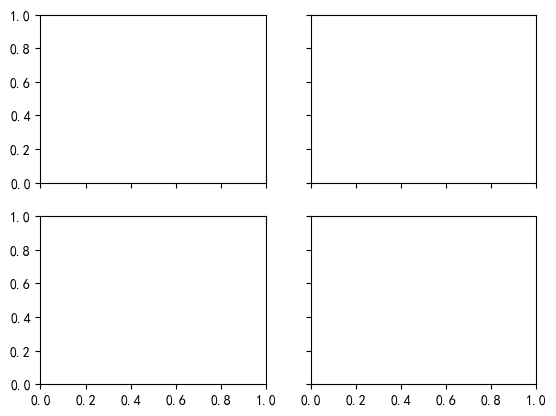

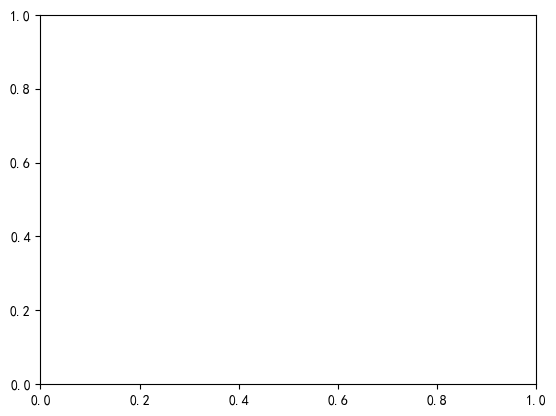

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

# 创建一些测试数据 -- 图1
x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x**2)

# 创建一个画像和子图 -- 图2
fig, ax = plt.subplots() 
ax.plot(x, y)
ax.set_title('Simple plot')

# 创建两个子图 -- 图3
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.plot(x, y)
ax1.set_title('Sharing Y axis')
ax2.scatter(x, y)

# 创建四个子图 -- 图4
fig, axs = plt.subplots(2, 2, subplot_kw=dict(projection="polar"))
axs[0, 0].plot(x, y)
axs[1, 1].scatter(x, y)

# 共享 x 轴
plt.subplots(2, 2, sharex='col')

# 共享 y 轴
plt.subplots(2, 2, sharey='row')

# 共享 x 轴和 y 轴
plt.subplots(2, 2, sharex='all', sharey='all')

# 这个也是共享 x 轴和 y 轴
plt.subplots(2, 2, sharex=True, sharey=True)

# 创建标识为 10 的图，已经存在的则删除
fig, ax = plt.subplots(num=10, clear=True)

plt.show()

## 二、绘制散点图

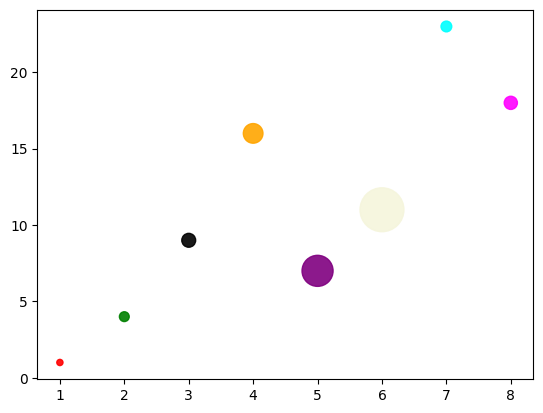

In [23]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([1, 4, 9, 16, 7, 11, 23, 18])

sizes = np.array([20,50,100,200,500,1000,60,90])
colors = np.array(["red","green","black","orange","purple","beige","cyan","magenta"])

plt.scatter(x, y, s=sizes, c=colors, alpha=0.9) # alpha设置透明度
plt.show()

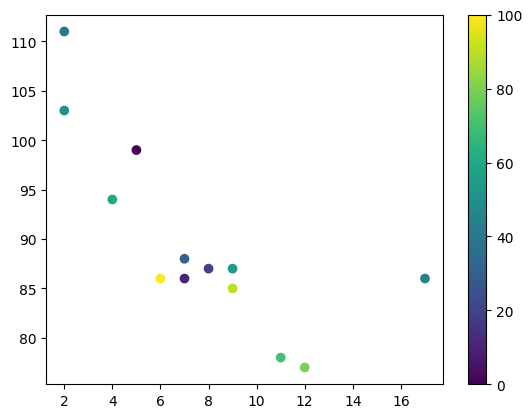

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([5,7,8,7,2,17,2,9,4,11,12,9,6])
y = np.array([99,86,87,88,111,86,103,87,94,78,77,85,86])
colors = np.array([0, 10, 20, 30, 40, 45, 50, 55, 60, 70, 80, 90, 100])

# viridis 是 matplotlib 的一个颜色映射
plt.scatter(x, y, c=colors, cmap='viridis')

# 添加颜色条，能够确定各种颜色对应的程度关系
plt.colorbar()

plt.show()

## 三、绘制柱状图

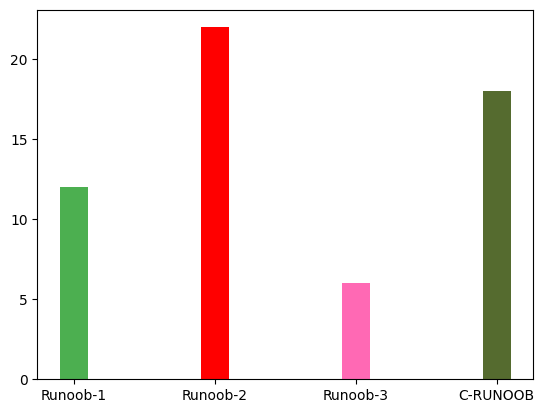

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array(["Runoob-1", "Runoob-2", "Runoob-3", "C-RUNOOB"])
y = np.array([12, 22, 6, 18])

# 竖直条形图
plt.bar(x, y,  color = ["#4CAF50","red","hotpink","#556B2F"], width=0.2)

# 水平条形图
# plt.barh(x, y,  color = ["#4CAF50","red","hotpink","#556B2F"], height=0.4)

plt.show()

## 四、绘制饼图
```python
    plt.pie(x, explode=None, labels=None, colors=None, autopct=None, pctdistance=0.6, shadow=False, labeldistance=1.1, startangle=0, radius=1, counterclock=True, wedgeprops=None, textprops=None, center=0, 0, frame=False, rotatelabels=False, *, normalize=None, data=None)
```

### 参数说明：

- x：浮点型数组或列表，用于绘制饼图的数据，表示每个扇形的面积。

- explode：数组，表示各个扇形之间的间隔，默认值为0。

- labels：列表，各个扇形的标签，默认值为 None。

- colors：数组，表示各个扇形的颜色，默认值为 None。

- autopct：设置饼图内各个扇形百分比显示格式，%d%% 整数百分比，%0.1f 一位小数， %0.1f%% 一位小数百分比， %0.2f%% 两位小数百分比。

- labeldistance：标签标记的绘制位置，相对于半径的比例，默认值为 1.1，如 <1则绘制在饼图内侧。

- pctdistance：：类似于 labeldistance，指定 autopct 的位置刻度，默认值为 0.6。

- shadow：：布尔值 True 或 False，设置饼图的阴影，默认为 False，不设置阴影。

- radius：：设置饼图的半径，默认为 1。

- startangle：：用于指定饼图的起始角度，默认为从 x 轴正方向逆时针画起，如设定 =90 则从 y 轴正方向画起。

- counterclock：布尔值，用于指定是否逆时针绘制扇形，默认为 True，即逆时针绘制，False 为顺时针。

- wedgeprops ：字典类型，默认值 None。用于指定扇形的属性，比如边框线颜色、边框线宽度等。例如：wedgeprops={'linewidth':5} 设置 wedge 线宽为5。
- textprops ：字典类型，用于指定文本标签的属性，比如字体大小、字体颜色等，默认值为 None。
- center ：浮点类型的列表，用于指定饼图的中心位置，默认值：(0,0)。
- frame ：布尔类型，用于指定是否绘制饼图的边框，默认值：False。如果是 True，绘制带有表的轴框架。
- rotatelabels ：布尔类型，用于指定是否旋转文本标签，默认为 False。如果为 True，旋转每个 label 到指定的角度。
- data：用于指定数据。如果设置了 data 参数，则可以直接使用数据框中的列作为 x、labels 等参数的值，无需再次传递。

除此之外，pie() 函数还可以返回三个参数：

- wedges：一个包含扇形对象的列表。

- texts：一个包含文本标签对象的列表。

- autotexts：一个包含自动生成的文本标签对象的列表。

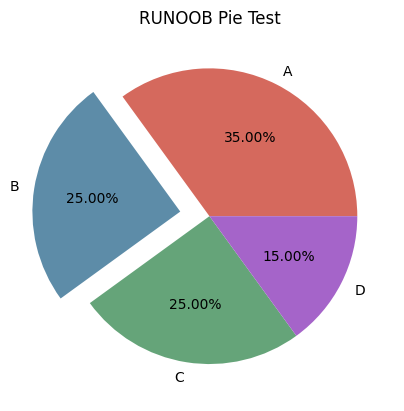

In [29]:
import matplotlib.pyplot as plt
import numpy as np

y = np.array([35, 25, 25, 15])

plt.pie(y,
        labels=['A','B','C','D'], # 设置饼图标签
        colors=["#d5695d", "#5d8ca8", "#65a479", "#a564c9"], # 设置饼图颜色
        explode=(0, 0.2, 0, 0), # 第二部分突出显示，值越大，距离中心越远
        autopct='%.2f%%', # 格式化输出百分比
       )
plt.title("RUNOOB Pie Test")
plt.show()

## 五、直方图

我们可以使用 pyplot 中的 hist() 方法来绘制直方图。

hist() 方法是 Matplotlib 库中的 pyplot 子库中的一种用于绘制直方图的函数。

hist() 方法可以用于可视化数据的分布情况，例如观察数据的中心趋势、偏态和异常值等。

```python
    plt.hist(x, bins=None, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', align='mid', orientation='vertical', rwidth=None, log=False, color=None, label=None, stacked=False, **kwargs)
```

### 参数说明
- x：表示要绘制直方图的数据，可以是一个一维数组或列表。
- bins：可选参数，表示直方图的箱数。默认为10。
- range：可选参数，表示直方图的值域范围，可以是一个二元组或列表。默认为None，即使用数据中的最小值和最大值。
- density：可选参数，表示是否将直方图归一化。默认为False，即直方图的高度为每个箱子内的样本数，而不是频率或概率密度。
- weights：可选参数，表示每个数据点的权重。默认为None。
- cumulative：可选参数，表示是否绘制累积分布图。默认为False。
- bottom：可选参数，表示直方图的起始高度。默认为None。
- histtype：可选参数，表示直方图的类型，可以是'bar'、'barstacked'、'step'、'stepfilled'等。默认为'bar'。
- align：可选参数，表示直方图箱子的对齐方式，可以是'left'、'mid'、'right'。默认为'mid'。
- orientation：可选参数，表示直方图的方向，可以是'vertical'、'horizontal'。默认为'vertical'。
- rwidth：可选参数，表示每个箱子的宽度。默认为None。
- log：可选参数，表示是否在y轴上使用对数刻度。默认为False。
- color：可选参数，表示直方图的颜色。
- label：可选参数，表示直方图的标签。
- stacked：可选参数，表示是否堆叠不同的直方图。默认为False。
- **kwargs：可选参数，表示其他绘图参数。

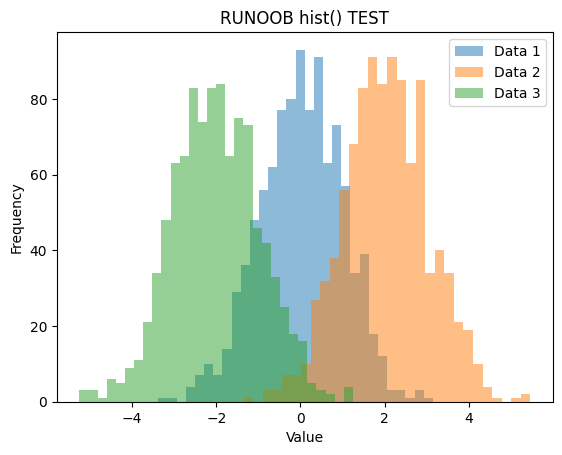

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 生成三组随机数据
data1 = np.random.normal(0, 1, 1000)
data2 = np.random.normal(2, 1, 1000)
data3 = np.random.normal(-2, 1, 1000)

# 绘制直方图
plt.hist(data1, bins=30, alpha=0.5, label='Data 1')
plt.hist(data2, bins=30, alpha=0.5, label='Data 2')
plt.hist(data3, bins=30, alpha=0.5, label='Data 3')

# 设置图表属性
plt.title('RUNOOB hist() TEST')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

# 显示图表
plt.show()

### 总述：以下是一些常用的 pyplot 函数：
- plot()：用于绘制线图和散点图
- scatter()：用于绘制散点图
- bar()：用于绘制垂直条形图和水平条形图
- hist()：用于绘制直方图
- pie()：用于绘制饼图
- imshow()：用于绘制图像
- subplots()：用于创建子图

### 参数说明：

- x, y：点或线的节点，x 为 x 轴数据，y 为 y 轴数据，数据可以列表或数组。
- fmt：可选，定义基本格式（如颜色、标记和线条样式）。
- **kwargs：可选，用在二维平面图上，设置指定属性，如标签，线的宽度等。
  - 颜色字符：
    - 'b' 蓝色，
    - 'm' 洋红色，
    - 'g' 绿色，
    - 'y' 黄色，
    - 'r' 红色，
    - 'k' 黑色，
    - 'w' 白色，
    - 'c' 青绿色，
    - '#008000' RGB 颜色符串。
        
    多条曲线不指定颜色时，会自动选择不同颜色。
  - 线型参数：
    - '‐' 实线，
    - '‐‐' 破折线，
    - '‐.' 点划线，
    - ':' 虚线。
  - 标记字符：
    - '.' 点标记，
    - ',' 像素标记(极小点)，
    - 'o' 实心圈标记，
    - 'v' 倒三角标记，
    - '^' 上三角标记，
    - '>' 右三角标记，
    - '<' 左三角标记...等等。

# 轴标签和标题

- plt.title("RUNOOB TEST TITLE")
- plt.xlabel("x - label")
- plt.ylabel("y - label")

## 标题与标签的定位
- title() 方法提供了 loc 参数来设置标题显示的位置，可以设置为: 'left', 'right', 和 'center'， 默认值为 'center'。
- xlabel() 方法提供了 loc 参数来设置 x 轴显示的位置，可以设置为: 'left', 'right', 和 'center'， 默认值为 'center'。
- ylabel() 方法提供了 loc 参数来设置 y 轴显示的位置，可以设置为: 'bottom', 'top', 和 'center'， 默认值为 'center'。

# figure的作用是
每个 plt.figure() 都会创建一个新的图形窗口，后续的绘图命令（如 plt.plot()、plt.imshow() 等）会作用于当前活跃的图形窗口。如果不指定，matplotlib 会自动创建一个默认的图形窗口。

## imshow()
imshow() 函数是 Matplotlib 库中的一个函数，用于显示图像。

imshow() 函数常用于绘制二维的灰度图像或彩色图像。

imshow() 函数可用于绘制矩阵、热力图、地图等。

```python
imshow(X, cmap=None, norm=None, aspect=None, interpolation=None, alpha=None, vmin=None, vmax=None, origin=None, extent=None, shape=None, filternorm=1, filterrad=4.0, imlim=None, resample=None, url=None, *, data=None, **kwargs)
```

## 参数说明：

- X：输入数据。可以是二维数组、三维数组、PIL图像对象、matplotlib路径对象等。
- cmap：颜色映射。用于控制图像中不同数值所对应的颜色。可以选择内置的颜色映射，如gray、hot、jet等，也可以自定义颜色映射。
- norm：用于控制数值的归一化方式。可以选择Normalize、LogNorm等归一化方法。
- aspect：控制图像纵横比（aspect ratio）。可以设置为auto或一个数字。
- interpolation：插值方法。用于控制图像的平滑程度和细节程度。可以选择nearest、bilinear、bicubic等插值方法。
- alpha：图像透明度。取值范围为0~1。
- origin：坐标轴原点的位置。可以设置为upper或lower。
- extent：控制显示的数据范围。可以设置为[xmin, xmax, ymin, ymax]。
- vmin、vmax：控制颜色映射的值域范围。
- filternorm 和 filterrad：用于图像滤波的对象。可以设置为None、antigrain、freetype等。
- imlim： 用于指定图像显示范围。
- resample：用于指定图像重采样方式。
- url：用于指定图像链接。

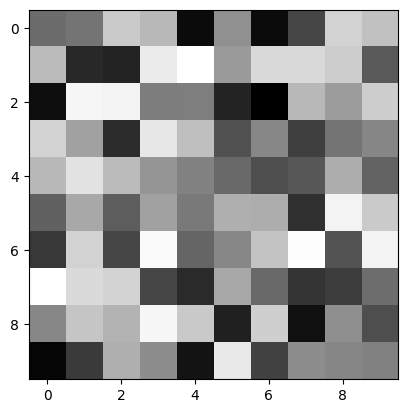

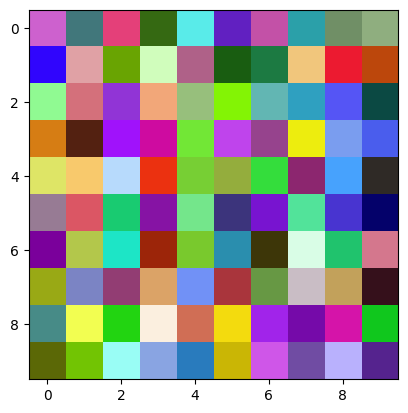

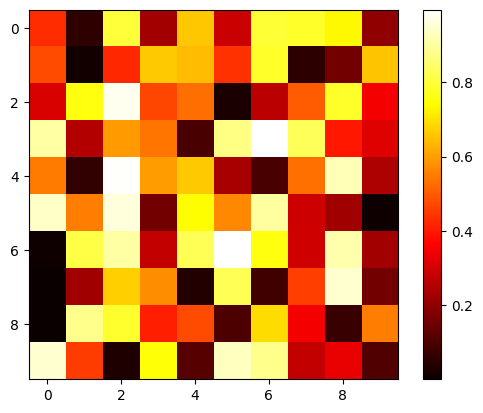

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 灰度图
img = np.random.rand(10, 10)
plt.imshow(img, cmap='gray')
plt.show()

# 彩色图
img = np.random.rand(10, 10, 3)
plt.imshow(img)
plt.show()

# 热力图
img = np.random.rand(10, 10)
plt.imshow(img, cmap='hot')
plt.colorbar()  # 添加颜色条
plt.show()

## imsave()
imsave() 方法是 Matplotlib 库中用于将图像数据保存到磁盘上的函数。

通过 imsave() 方法我们可以轻松将生成的图像保存到我们指定的目录中。

imsave() 方法保存图片支持多种图像格式，例如 PNG、JPEG、BMP 等。

matplotlib.pyplot.imsave(fname, arr, **kwargs)

## 参数说明：
- fname：保存图像的文件名，可以是相对路径或绝对路径。
- arr：表示图像的NumPy数组。
- kwargs：可选参数，用于指定保存的图像格式以及图像质量等参数。

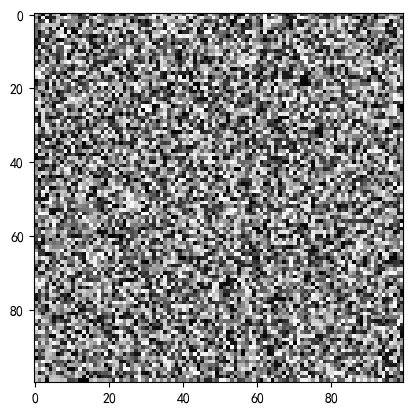

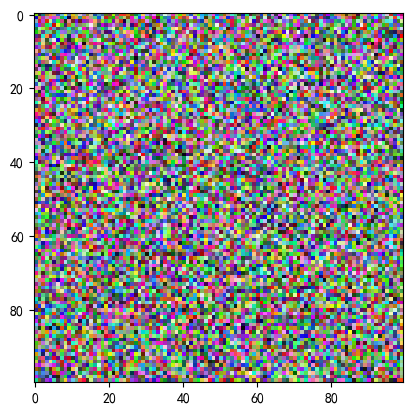

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 创建一幅灰度图像
img_gray = np.random.random((100, 100))

# 创建一幅彩色图像
# img_color = np.zeros((100, 100, 3))
# img_color[:, :, 0] = np.random.random((100, 100))
# img_color[:, :, 1] = np.random.random((100, 100))
# img_color[:, :, 2] = np.random.random((100, 100))
img_color = np.random.random((100, 100, 3))

# 显示灰度图像
plt.imshow(img_gray, cmap='gray')
plt.show()

# 保存灰度图像到磁盘上
# plt.imsave('test_gray.png', img_gray, cmap='gray')

# 显示彩色图像
plt.imshow(img_color)
plt.show()

# 保存彩色图像到磁盘上
# plt.imsave('test_color.jpg', img_color)

## imread()

imread() 方法是 Matplotlib 库中的一个函数，用于从图像文件中读取图像数据。

imread() 方法返回一个 numpy.ndarray 对象，其形状是 (nrows, ncols, nchannels)，表示读取的图像的行数、列数和通道数：

- 如果图像是灰度图像，则 nchannels 为 1。
- 如果是彩色图像，则 nchannels 为 3 或 4，分别表示红、绿、蓝三个颜色通道和一个 alpha 通道。

matplotlib.pyplot.imread(fname, format=None)

## 参数说明：
- fname：指定了要读取的图像文件的文件名或文件路径，可以是相对路径或绝对路径。
- format ：参数指定了图像文件的格式，如果不指定，则默认根据文件后缀名来自动识别格式。

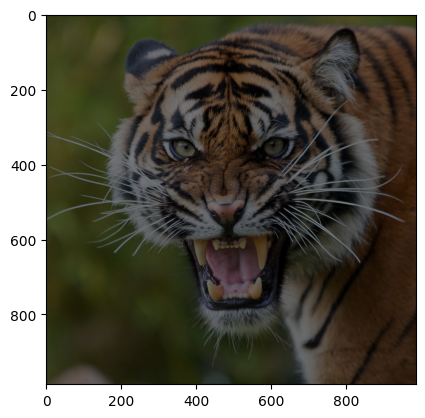

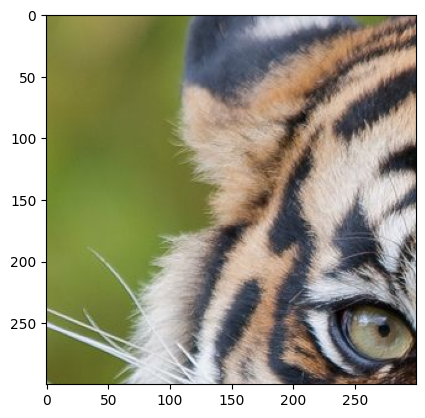

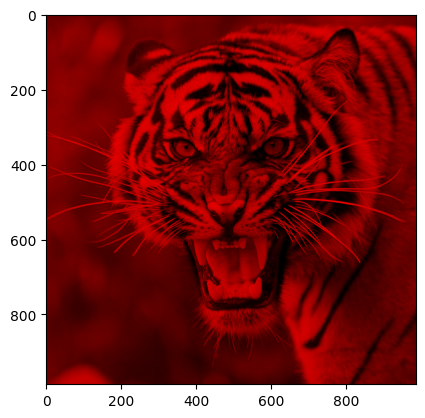

In [6]:
import matplotlib.pyplot as plt

# 读取图像文件，下载地址：https://static.jyshare.com/images/mix/tiger.jpeg
# 返回numpy数组
img_array = plt.imread('tiger.jpeg')

# 将图像变暗
tiger = img_array/2
plt.imshow(tiger)
plt.show()

# 裁剪图像
tiger_cropped = img_array[100:400, 100:400]
plt.imshow(tiger_cropped)
plt.show()

# 将图像的某些通道变为0
tiger_no_red = img_array.copy()
tiger_no_red[:, :, 1] = 0  # 将绿色通道
tiger_no_red[:, :, 2] = 0  # 将蓝色通道
plt.imshow(tiger_no_red)
plt.show()

# 中文显示

Matplotlib 中文显示不是特别友好，要在 Matplotlib 中显示中文，我们可以通过两个方法：

- 设置 Matplotlib 的字体参数。
- 下载使用支持中文的字体库。

## 支持的中文字体
- SimHei（黑体）
- SimSun（宋体）
- KaiTi（楷体）
- FangSong（仿宋）
- Microsoft YaHei（微软雅黑）
- STSong（华文宋体）
- STKaiti（华文楷体）

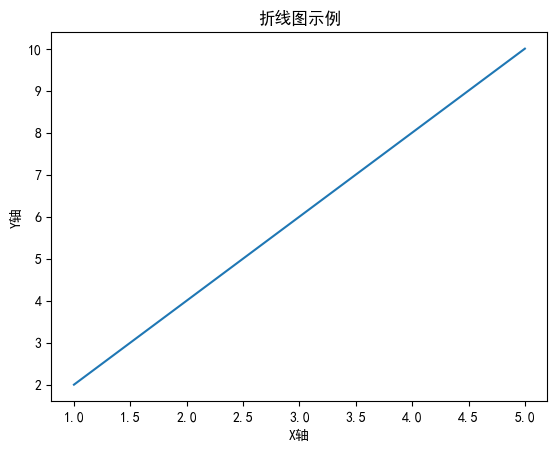

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'SimHei'  # 替换为你选择的字体
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

# 创建数据
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# 绘制折线图
plt.plot(x, y)

# 添加标题和标签
plt.title('折线图示例')
plt.xlabel('X轴')
plt.ylabel('Y轴')

# 显示图形
plt.show()